In [97]:
import numpy as np
import matplotlib.pyplot as plt

In [98]:
x = np.array([0.142, 0.494, 0.847, 1.199, 1.552, 1.904, 2.257, 2.609, 2.962])
y = np.array([5.642, 4.096, 3.390, 2.924, 2.775, 2.534, 2.418, 2.405, 2.298])

n = len(x)

In [99]:
sum_x  = np.sum(x)
sum_x2 = np.sum(x**2)
sum_y  = np.sum(y)
sum_xy = np.sum(x * y)

A_lin = np.array([[sum_x2, sum_x], 
                  [sum_x, n]])
B_lin = np.array([sum_xy, sum_y])

a_lin, b_lin = np.linalg.solve(A_lin, B_lin)
y_lin = a_lin * x + b_lin
delta_lin = np.sum((y - y_lin)**2)

In [100]:
print("Линейная аппроксимация y = ax + b")
print(f"Коэффициенты: a = {a_lin:.4f}, b = {b_lin:.4f}")
print(f"Невязка δ = {delta_lin:.6f}\n")

Линейная аппроксимация y = ax + b
Коэффициенты: a = -0.9826, b = 4.6894
Невязка δ = 2.350357



In [101]:
sum_x3 = np.sum(x**3)
sum_x4 = np.sum(x**4)
sum_xy2 = np.sum(x**2 * y)

In [102]:
A_quad = np.array([[sum_x4, sum_x3, sum_x2],
                   [sum_x3, sum_x2, sum_x],
                   [sum_x2, sum_x, n]])
B_quad = np.array([sum_xy2, sum_xy, sum_y])

a_q, b_q, c_q = np.linalg.solve(A_quad, B_quad)
y_quad = a_q * x**2 + b_q * x + c_q
delta_quad = np.sum((y - y_quad)**2)

In [103]:
print("Квадратичная аппроксимация y = ax² + bx + c")
print(f"Коэффициенты: a = {a_q:.4f}, b = {b_q:.4f}, c = {c_q:.4f}")
print(f"Невязка δ = {delta_quad:.6f}\n")

Квадратичная аппроксимация y = ax² + bx + c
Коэффициенты: a = 0.6365, b = -2.9580, c = 5.6950
Невязка δ = 0.424001



In [104]:
Y = np.log(y)
A_nl = np.array([[n, sum_x], 
                 [sum_x, sum_x2]])
B_nl = np.array([np.sum(Y), np.sum(x * Y)])

ln_a, b_nl = np.linalg.solve(A_nl, B_nl)
a_nl = np.exp(ln_a)
y_nl = a_nl * np.exp(b_nl * x)
delta_nl = np.sum((y - y_nl)**2)

In [105]:
print("Линеаризация y = a*e^(bx)")
print(f"Коэффициенты: a = {a_nl:.4f}, b = {b_nl:.4f}")
print(f"Невязка δ = {delta_nl:.6f}\n")

Линеаризация y = a*e^(bx)
Коэффициенты: a = 4.7088, b = -0.2841
Невязка δ = 1.740915



In [106]:
def calc_rms(delta, n):
    return np.sqrt(delta / n)

s_lin  = calc_rms(delta_lin, n)
s_quad = calc_rms(delta_quad, n)
s_nl   = calc_rms(delta_nl, n)

In [107]:
print("Среднеквадратичная ошибка s = √(δ/n)")
print(f"Линейная:    s = {s_lin:.6f}")
print(f"Квадратичная: s = {s_quad:.6f}")
print(f"Нелинейная:  s = {s_nl:.6f}")

Среднеквадратичная ошибка s = √(δ/n)
Линейная:    s = 0.511029
Квадратичная: s = 0.217051
Нелинейная:  s = 0.439813


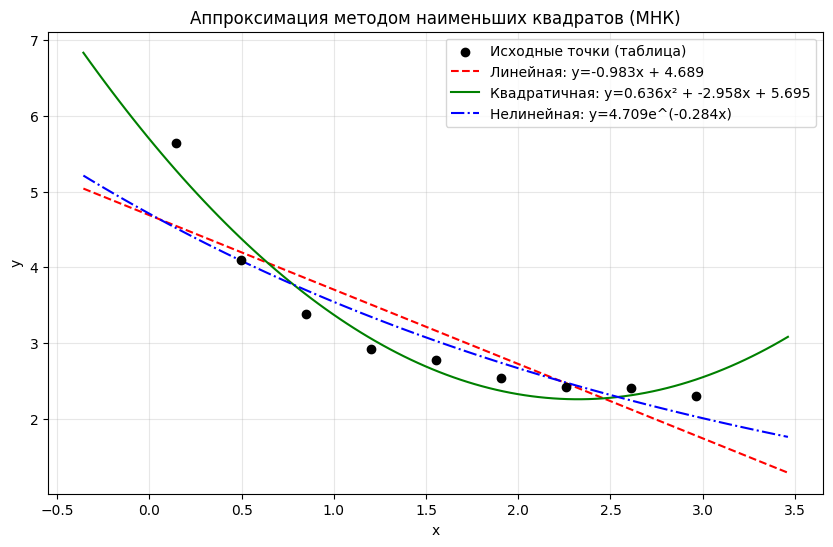

In [108]:
x_plot = np.linspace(min(x)-0.5, max(x)+0.5, 100)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', zorder=5, label='Исходные точки (таблица)')
plt.plot(x_plot, a_lin*x_plot + b_lin, 'r--', label=f'Линейная: y={a_lin:.3f}x + {b_lin:.3f}')
plt.plot(x_plot, a_q*x_plot**2 + b_q*x_plot + c_q, 'g-', label=f'Квадратичная: y={a_q:.3f}x² + {b_q:.3f}x + {c_q:.3f}')
plt.plot(x_plot, a_nl*np.exp(b_nl*x_plot), 'b-.', label=f'Нелинейная: y={a_nl:.3f}e^({b_nl:.3f}x)')

plt.title('Аппроксимация методом наименьших квадратов (МНК)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()